# Fig. 8：四条曲线统一采用新 Prada12 质量吸积史

本 Notebook 重新计算论文 Fig. 8，但把“质量吸积史”和“计算每晕捕获率时使用的浓度模型”明确分开：

- 今天的晕质量 $M_0$ 在 $10^3$--$10^{15}M_\odot$ 之间取 50 个对数等距节点；
- 四条曲线的 $M(z;M_0)$ 全部由新 Prada12（WMAP5/HMF $\sigma$）在 $z=0$ 的浓度和 Appendix C 公式得到；
- 标记为 Ludlow16 的两条曲线只在计算 $R_{\rm halo}[M(z),z]$ 时使用 Ludlow16 浓度；
- 标记为 Prada12 的两条曲线在计算 $R_{\rm halo}$ 时显式使用 `prada12_hmf_sigma` 新模型；
- 单色与对数正态两种 PBH 质量函数仍分别计算，所以共有四条曲线。

这是一项模型替换实验，不等同于论文原始 Fig. 8 的吸积史设置。

In [1]:
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "twobodycapture.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import haloconcentration as hc
import pbhmassfunction as pmf
import twobodycapture as capture

print(f"项目目录：{PROJECT_ROOT}")

项目目录：D:\pbh formation\pbh merge\2body channel and numerical simulation


## 1. 红移网格、50 个 $M_0$ 节点和 PBH 质量分布

红移取论文图中的 $z=0,1,\ldots,12$。主体函数会在指定范围内自动建立 50 个 $M_0$ 节点；这里同时显式生成同一网格，方便查看。

In [2]:
REDSHIFT = np.arange(0.0, 13.0, 1.0)
MINIMUM_PRESENT_HALO_MASS_MSUN = 1.0e3
MAXIMUM_PRESENT_HALO_MASS_MSUN = 1.0e15
HALO_TRACK_POINT_COUNT = 50
F_PBH = 1.0

present_day_mass_nodes_msun = np.geomspace(
    MINIMUM_PRESENT_HALO_MASS_MSUN,
    MAXIMUM_PRESENT_HALO_MASS_MSUN,
    HALO_TRACK_POINT_COUNT,
)

monochromatic_nodes, monochromatic_weights = (
    pmf.monochromatic_mass_distribution(mass_msun=30.0)
)

def figure8_lognormal_pdf(mass_msun):
    return pmf.lognormal_mass_pdf(
        mass_msun,
        median_mass_msun=30.0,
        sigma=0.6,
        mass_min_msun=5.0,
        mass_max_msun=150.0,
    )

lognormal_nodes, lognormal_weights = pmf.continuous_mass_quadrature(
    figure8_lognormal_pdf,
    mass_min_msun=5.0,
    mass_max_msun=150.0,
    point_count=96,
)

print(f"红移点数：{REDSHIFT.size}")
print(f"M0 节点数：{present_day_mass_nodes_msun.size}")
print(
    f"M0 范围：{present_day_mass_nodes_msun[0]:.1e} -- "
    f"{present_day_mass_nodes_msun[-1]:.1e} M_sun"
)

红移点数：13
M0 节点数：50
M0 范围：1.0e+03 -- 1.0e+15 M_sun


## 2. 四条曲线共用的新 Prada12 吸积史

总率函数会把当前曲线的浓度模型名称作为第三个参数传入回调。这里故意不使用该名称，而是始终指定 `prada12_hmf_sigma`，保证 Ludlow16 和 Prada12 四条曲线拥有完全相同的 $M(z;M_0)$。

In [3]:
def new_prada12_mass_history(
    mass0_msun,
    z,
    _rate_concentration_model,
):
    """用新 Prada12 的 C(M0,0) 和 Appendix C 返回 M(z;M0)。"""
    return hc.mass_accretion_history(
        mass0_msun,
        z,
        model="prada12_hmf_sigma",
    )

example_track_masses = new_prada12_mass_history(
    present_day_mass_nodes_msun,
    6.0,
    "ludlow16",
)
print(
    "z=6 时首末两条新 Prada12 轨迹的质量："
    f"{example_track_masses[0]:.6e}, "
    f"{example_track_masses[-1]:.6e} M_sun"
)

z=6 时首末两条新 Prada12 轨迹的质量：2.811076e+02, 2.573487e+12 M_sun


## 3. 计算四条总并合率曲线

四次调用都传入同一个 `new_prada12_mass_history`。唯一改变的是 PBH 质量分布和用于计算每晕率的浓度模型。

In [4]:
def calculate_figure8_curve(
    rate_concentration_model,
    mass_nodes_msun,
    mass_probability_weights,
    curve_label,
):
    values = []
    for z in REDSHIFT:
        rate = capture.comoving_capture_rate_with_history_gpc3_per_year(
            z=z,
            mass_nodes_msun=mass_nodes_msun,
            mass_probability_weights=mass_probability_weights,
            mass_history_function=new_prada12_mass_history,
            concentration_model=rate_concentration_model,
            f_pbh=F_PBH,
            minimum_present_halo_mass_msun=(
                MINIMUM_PRESENT_HALO_MASS_MSUN
            ),
            maximum_present_halo_mass_msun=(
                MAXIMUM_PRESENT_HALO_MASS_MSUN
            ),
            halo_track_point_count=HALO_TRACK_POINT_COUNT,
        )
        values.append(rate)
        print(
            f"{curve_label:35s} z={z:2.0f}, "
            f"R={rate:10.4f} Gpc^-3 yr^-1"
        )
    return np.asarray(values)

start_time = time.perf_counter()

fig8_mono_ludlow = calculate_figure8_curve(
    "ludlow16",
    monochromatic_nodes,
    monochromatic_weights,
    "mono. + Ludlow16 c + Prada MAH",
)
fig8_lognormal_ludlow = calculate_figure8_curve(
    "ludlow16",
    lognormal_nodes,
    lognormal_weights,
    "log-normal + Ludlow16 c + Prada MAH",
)
fig8_mono_prada = calculate_figure8_curve(
    "prada12_hmf_sigma",
    monochromatic_nodes,
    monochromatic_weights,
    "mono. + new Prada12 c + Prada MAH",
)
fig8_lognormal_prada = calculate_figure8_curve(
    "prada12_hmf_sigma",
    lognormal_nodes,
    lognormal_weights,
    "log-normal + new Prada12 c + Prada MAH",
)

print(f"四条曲线耗时：{time.perf_counter() - start_time:.1f} s")

mono. + Ludlow16 c + Prada MAH      z= 0, R=    0.9104 Gpc^-3 yr^-1


mono. + Ludlow16 c + Prada MAH      z= 1, R=    1.7546 Gpc^-3 yr^-1


mono. + Ludlow16 c + Prada MAH      z= 2, R=    3.2270 Gpc^-3 yr^-1


mono. + Ludlow16 c + Prada MAH      z= 3, R=    4.9747 Gpc^-3 yr^-1


mono. + Ludlow16 c + Prada MAH      z= 4, R=    7.4106 Gpc^-3 yr^-1


...

log-normal + new Prada12 c + Prada MAH z= 8, R=   37.0383 Gpc^-3 yr^-1


log-normal + new Prada12 c + Prada MAH z= 9, R=   52.6774 Gpc^-3 yr^-1


log-normal + new Prada12 c + Prada MAH z=10, R=   73.3279 Gpc^-3 yr^-1


log-normal + new Prada12 c + Prada MAH z=11, R=  100.2609 Gpc^-3 yr^-1


log-normal + new Prada12 c + Prada MAH z=12, R=  135.0510 Gpc^-3 yr^-1
四条曲线耗时：12.9 s


## 4. 导出数据并绘制新 Fig. 8

文件名增加 `all_new_prada_history`，避免覆盖原始复现结果。

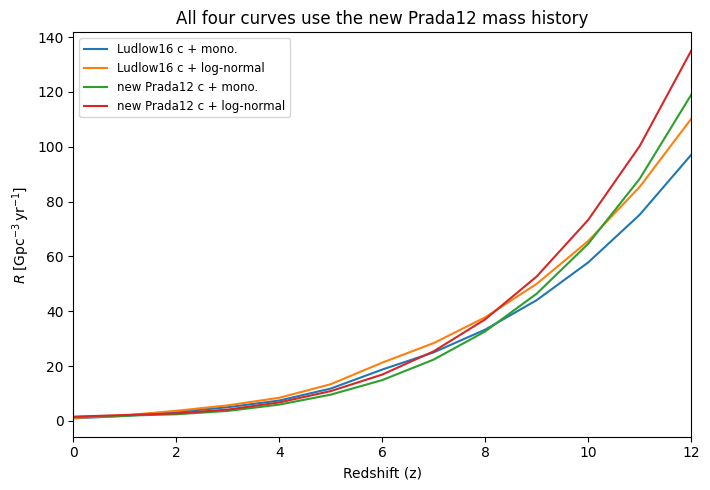

CSV 已保存：D:\pbh formation\pbh merge\2body channel and numerical simulation\fig8_all_new_prada_history.csv
新 Fig. 8 已保存：D:\pbh formation\pbh merge\2body channel and numerical simulation\fig8_all_new_prada_history.png


In [5]:
output_columns = np.column_stack([
    REDSHIFT,
    fig8_mono_ludlow,
    fig8_lognormal_ludlow,
    fig8_mono_prada,
    fig8_lognormal_prada,
])
csv_path = PROJECT_ROOT / "fig8_all_new_prada_history.csv"
np.savetxt(
    csv_path,
    output_columns,
    delimiter=",",
    header=(
        "z,mono_ludlow_c_new_prada_mah,"
        "lognormal_ludlow_c_new_prada_mah,"
        "mono_new_prada_c_new_prada_mah,"
        "lognormal_new_prada_c_new_prada_mah"
    ),
    comments="",
)

figure, axis = plt.subplots(figsize=(7.2, 5.0))
axis.plot(
    REDSHIFT, fig8_mono_ludlow, color="tab:blue",
    label="Ludlow16 c + mono.",
)
axis.plot(
    REDSHIFT, fig8_lognormal_ludlow, color="tab:orange",
    label="Ludlow16 c + log-normal",
)
axis.plot(
    REDSHIFT, fig8_mono_prada, color="tab:green",
    label="new Prada12 c + mono.",
)
axis.plot(
    REDSHIFT, fig8_lognormal_prada, color="tab:red",
    label="new Prada12 c + log-normal",
)
axis.set_xlim(0.0, 12.0)
axis.set_xlabel("Redshift (z)")
axis.set_ylabel(r"$R\;[\mathrm{Gpc}^{-3}\,\mathrm{yr}^{-1}]$")
axis.set_title("All four curves use the new Prada12 mass history")
axis.legend(frameon=True, fontsize=8.5)
figure.tight_layout()
figure_path = PROJECT_ROOT / "fig8_all_new_prada_history.png"
figure.savefig(figure_path, dpi=240, bbox_inches="tight")
plt.show()

print(f"CSV 已保存：{csv_path}")
print(f"新 Fig. 8 已保存：{figure_path}")